In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

In [2]:
def Process_WaterPhantomData(filepath):
    #####
    # Process csv data for water phantom, obtained from LET export script, into a line dose

    # INPUTS 
    # filepath = path to csv file
    # 
    # OUTPUTS 
    # dosedata = dose data along central line of phantom
    # letdata = LET data along central line of phantom

    data_waterphantom = pd.read_csv(filepath)

    #Find middle x and y
    x_mid = np.unique(data_waterphantom['x_mm'])[round(len(np.unique(data_waterphantom['x_mm']))/2)]
    z_mid = np.unique(data_waterphantom['z_mm'])[round(len(np.unique(data_waterphantom['z_mm']))/2)]

    #Extract data with this x and y
    lineprofile = data_waterphantom[(data_waterphantom['x_mm']==x_mid) & (data_waterphantom['z_mm']==z_mid)]

    #Process data
    ydata = np.array(abs(lineprofile['y_mm']))
    let = np.array(lineprofile['LET_keV_per_um'])
    dose = np.array(lineprofile['Physical_dose'])

    #Want depth to start at zero
    ydata = ydata - min(ydata)
    #Sort depth data in ascending order
    sort = np.argsort(ydata)
    #Apply sorting to all variables
    ydata = ydata[sort]
    let = let[sort]
    dose = dose[sort]

    #normalise dose data
    dose = dose/max(dose)

    #Truncate data once dose drops to zero
    stopindex = np.where(dose<0.01)[0][0]
    ydata = ydata[0:stopindex]
    let = let[0:stopindex]
    dose = dose[0:stopindex]

    #Write to pandas
    let = pd.DataFrame({'y_mm': ydata, 'LET': let})
    dose = pd.DataFrame({'y_mm': ydata, 'Dose': dose})

    return dose, let

## Processing of dose and LET data in water phantom

This is the data that I got from running a simulation of a 69.87 MeV beam in a water phantom. .

In [3]:
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Water phantom data new energy\Pristine 69.87 MeV in Water Phantom.csv"

dosedata, letdata = Process_WaterPhantomData(path)

#print(dosedata)
#print(letdata)

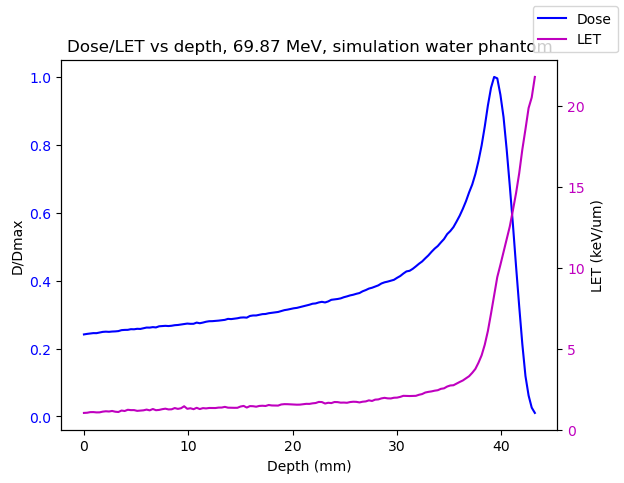

In [4]:
#Plot lineprofile as function of depth
fig, ax1 = plt.subplots()

ax1.plot(dosedata['y_mm'], dosedata['Dose'], label='Dose', color='b')
ax1.set_xlabel('Depth (mm)')
ax1.set_ylabel('D/Dmax')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(letdata['y_mm'], letdata['LET'], label='LET', color='m')
ax2.set_ylabel('LET (keV/um)')
ax2.tick_params(axis='y', labelcolor='m')

plt.title('Dose/LET vs depth, 69.87 MeV, simulation water phantom')

fig.legend()

# Validation of simulation against measured data

On 10/2/2026 I did dosimetry to plot the Bragg Peak at 69.87 MeV. Compare this against simulation data as a benchmark.
Looks like the simulation in water phantom is a good match to measured data.

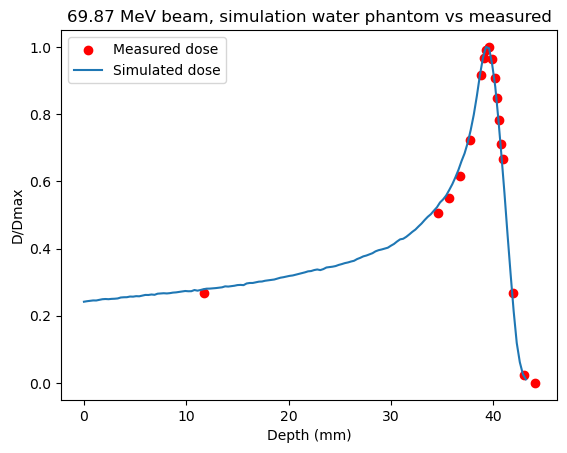

In [5]:
BP_measured = pd.read_excel(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Mid LET calculation\BP 69.87 measured - copy for scripts.xlsx")

RSdepth_m = np.array(BP_measured['Depth (mm)'])
RSdose_m = np.array(BP_measured['Dose (Gy)'])

#Sort depth data in ascending order
sort = np.argsort(RSdepth_m)
#Apply sorting to all variables
RSdepth_m = RSdepth_m[sort]
RSdose_m = RSdose_m[sort]

#Want dose normalised to maximum
RSdose_m = RSdose_m/max(RSdose_m)

plt.scatter(RSdepth_m, RSdose_m, label='Measured dose', color='r')
plt.plot(dosedata['y_mm'], dosedata['Dose'], label='Simulated dose')
plt.title('69.87 MeV beam, simulation water phantom vs measured')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()
plt.savefig(r"C:\Users\bhaan\Downloads\Water phantom dose alongside dosimetry 300 dpi.png", dpi=300)

## Calculating LET in irradiation positions

First interpolate the existing LET and dose data to get a good lookup table for calculations

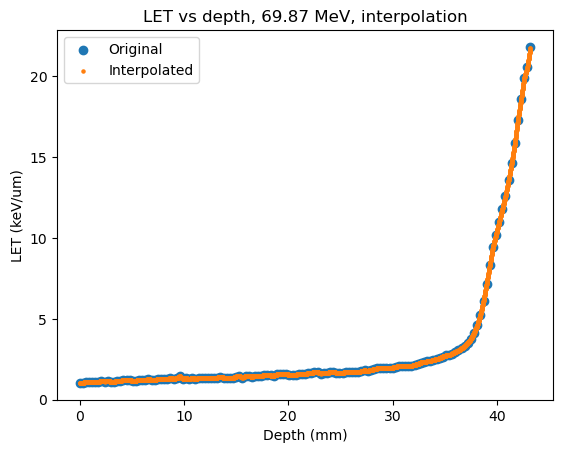

In [6]:
#interpolate data to get depth in steps of 0.01 mm
LET_interp = pd.DataFrame(columns=['Depth', 'LET'])
LET_interp['Depth'] = np.arange(np.array(letdata['y_mm'])[0], np.array(letdata['y_mm'])[-1], 0.01)

LET_interp['LET'] = np.interp(LET_interp['Depth'], np.array(letdata['y_mm']), np.array(letdata['LET']))

plt.scatter(letdata['y_mm'], letdata['LET'], label='Original')
plt.scatter(LET_interp['Depth'], LET_interp['LET'], label='Interpolated', s=5)
plt.title('LET vs depth, 69.87 MeV, interpolation')
plt.xlabel('Depth (mm)')
plt.ylabel('LET (keV/um)')
plt.legend()

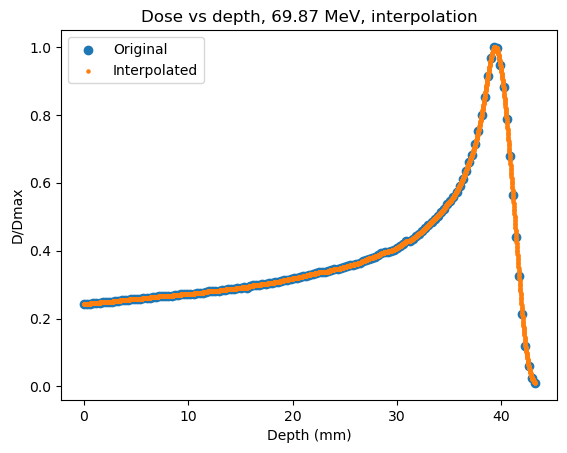

In [7]:
LET_interp['Dose'] = np.interp(LET_interp['Depth'], np.array(dosedata['y_mm']), np.array(dosedata['Dose']))

plt.scatter(dosedata['y_mm'], dosedata['Dose'], label='Original')
plt.scatter(LET_interp['Depth'], LET_interp['Dose'], label='Interpolated', s=5)
plt.title('Dose vs depth, 69.87 MeV, interpolation')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()

Below is the WET data for the attributes that we use.

![alt text](<../Mid LET calculation/WET data.jpeg>)

First verify the existing irradiation positions.

---Low LET---

Low LET position = 10 mm solid water plate + flask bottom

In WET this equals 10.44 mm + 1.34685 = 11.79 mm

So low LET = 11.79 mm depth


---High LET---

High LET position = 10 mm solid water plate + flask bottom + 2 cm range shifter + 7 mm solid water

In WET this equals 10.44 + 1.34685 + 22.84 + 1.05 + 3*(2.11) = 42.01 mm

So high LET is expected at 42.01 mm depth



Expected difference between them is 30.22 mm

In [8]:
#Define low LET position at 11.79 mm depth
start = 1179
low_LET_position = LET_interp.iloc[start]
print('-----Low LET position-----')
print(low_LET_position)

-----Low LET position-----
Depth    11.790000
LET       1.319042
Dose      0.279454
Name: 1179, dtype: float64


In [9]:
#Isolate back end of Bragg peak
back_Bragg = LET_interp.iloc[np.argmax(np.array(LET_interp['Dose'])):len(LET_interp)]
back_Bragg['Diff'] = np.zeros(len(back_Bragg))
#calculate difference with entrance dose
for i in back_Bragg.index:
    diff = abs(back_Bragg.loc[i, 'Dose'] - low_LET_position['Dose'])
    back_Bragg.loc[i, 'Diff'] = diff

#high LET position is where the difference in dose is minimal
high_LET_position = back_Bragg.iloc[np.argmin(np.array(back_Bragg['Diff']))]

print('-----High LET position-----')
print(high_LET_position)

-----High LET position-----
Depth    41.820000
LET      16.452439
Dose      0.279796
Diff      0.000341
Name: 4182, dtype: float64


C:\Users\bhaan\AppData\Local\Temp\ipykernel_31340\561804332.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  back_Bragg['Diff'] = np.zeros(len(back_Bragg))


To conclude:

low LET = 1.3 keV/um

high LET = 16.5 keV/um

## Finding a mid LET

Aim = $1.3 + \frac{16.5-1.3}{2}$ = 8.9 keV/um

So ballpark we're aiming for ~ 9 keV/um

In [10]:
#Calculate difference with 9 keV/um
LET_interp['Diff_9'] = np.zeros(len(LET_interp))

for i in LET_interp.index:
    LET_interp.loc[i, 'Diff_9'] = abs(9 - LET_interp.loc[i, 'LET'])

mid_LET_position = LET_interp.iloc[np.argmin(np.array(LET_interp['Diff_9']))]

print(mid_LET_position)

Depth     39.480000
LET        8.990969
Dose       0.997448
Diff_9     0.009031
Name: 3948, dtype: float64


Depth 38.48 would reasonably give us 39.48 - 22.84 (range) - 10.44 (10 mm sw plate) - 1.35 (flask bottom) = 4.85 mm WET worth of solid water plates.

That translates to 4.85/2.11 = 2.3 ~ 2.5 solid water plates of 2 mm a.k.a. 5 mm solid water.

Matches the measurement data: 'Range2 + 5 mm' places us just a bit behind the BP

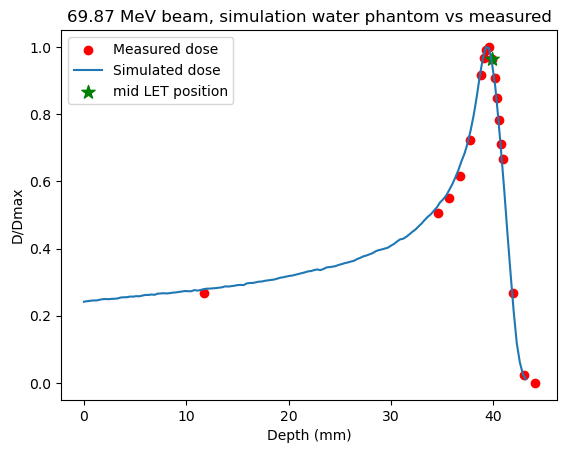

In [11]:
#mid LET position
mid = BP_measured[(BP_measured['Energy']==69.87) & (BP_measured['Material']=='Range2 + 5 mm')]
 
plt.scatter(RSdepth_m, RSdose_m, label='Measured dose', color='r')
plt.plot(dosedata['y_mm'], dosedata['Dose'], label='Simulated dose')
plt.scatter(mid['Depth (mm)'], mid['Dose (Gy)']/max(BP_measured['Dose (Gy)']), marker = '*', s = 100, color = 'green', label='mid LET position')
plt.title('69.87 MeV beam, simulation water phantom vs measured')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()
plt.savefig(r"C:\Users\bhaan\Downloads\Water phantom dose alongside dosimetry 300 dpi.png", dpi=300)

Where this gets us in terms of dose and LET:

Depth = 39.87

In [12]:
mid_LET_position = LET_interp.iloc[3987]
print(mid_LET_position)

Depth     39.870000
LET       10.125024
Dose       0.952210
Diff_9     1.125024
Name: 3987, dtype: float64


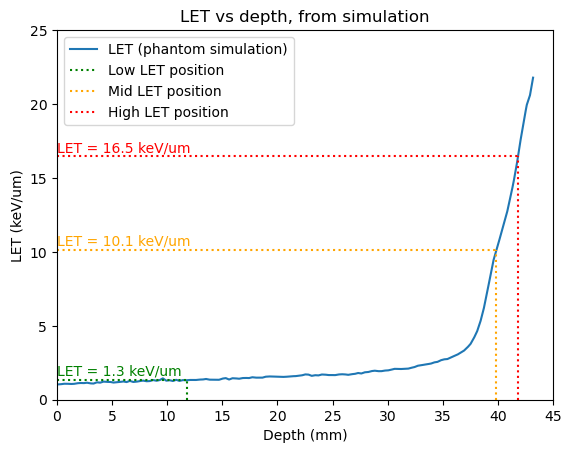

In [13]:
#Plotting the found positions on the LET curve
plt.plot(LET_interp['Depth'], LET_interp['LET'], label='LET (phantom simulation)')
plt.title('LET vs depth, from simulation')
plt.xlabel('Depth (mm)')
plt.ylabel('LET (keV/um)')
plt.xlim([0, 45])
plt.ylim([0, 25])

#low position
plt.hlines(low_LET_position['LET'], 0, low_LET_position['Depth'], colors='green', linestyles='dotted', label='Low LET position')
plt.vlines(low_LET_position['Depth'], 0, low_LET_position['LET'], colors='green', linestyles='dotted')
plt.text(0, low_LET_position['LET'] + 0.3, f'LET = {round(low_LET_position['LET'],1)} keV/um', fontsize=10, color='green')

#mid position
plt.hlines(mid_LET_position['LET'], 0, mid_LET_position['Depth'], colors='orange', linestyles='dotted', label='Mid LET position')
plt.vlines(mid_LET_position['Depth'], 0, mid_LET_position['LET'], colors='orange', linestyles='dotted')
plt.text(0, mid_LET_position['LET'] + 0.3, f'LET = {round(mid_LET_position['LET'],1)} keV/um', fontsize=10, color='orange')

#high position
plt.hlines(high_LET_position['LET'], 0, high_LET_position['Depth'], colors='red', linestyles='dotted', label='High LET position')
plt.vlines(high_LET_position['Depth'], 0, high_LET_position['LET'], colors='red', linestyles='dotted')
plt.text(0, high_LET_position['LET'] + 0.3, f'LET = {round(high_LET_position['LET'],1)} keV/um', fontsize=10, color='red')

plt.legend()

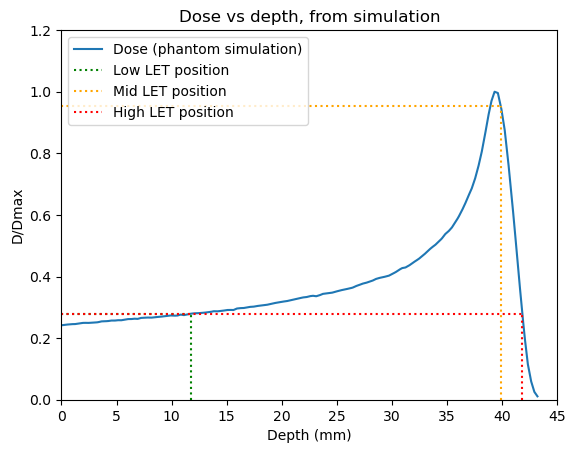

In [14]:
#Plotting the found positions on the dose curve
plt.plot(LET_interp['Depth'], LET_interp['Dose'], label='Dose (phantom simulation)')
plt.title('Dose vs depth, from simulation')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.xlim([0, 45])
plt.ylim([0, 1.2])

#low position
plt.hlines(low_LET_position['Dose'], 0, low_LET_position['Depth'], colors='green', linestyles='dotted', label='Low LET position')
plt.vlines(low_LET_position['Depth'], 0, low_LET_position['Dose'], colors='green', linestyles='dotted')

#mid position
plt.hlines(mid_LET_position['Dose'], 0, mid_LET_position['Depth'], colors='orange', linestyles='dotted', label='Mid LET position')
plt.vlines(mid_LET_position['Depth'], 0, mid_LET_position['Dose'], colors='orange', linestyles='dotted')

#high position
plt.hlines(high_LET_position['Dose'], 0, high_LET_position['Depth'], colors='red', linestyles='dotted', label='High LET position')
plt.vlines(high_LET_position['Depth'], 0, high_LET_position['Dose'], colors='red', linestyles='dotted')

plt.legend()

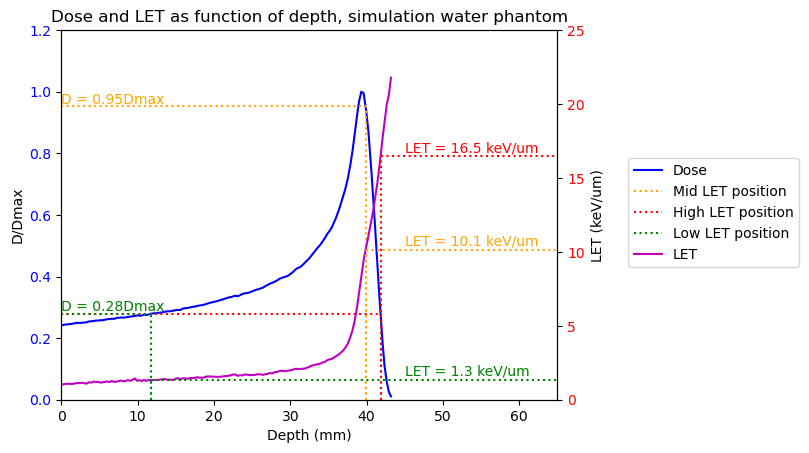

In [15]:
#Plot lineprofile as function of depth
fig, ax1 = plt.subplots()

#plot dose
ax1.plot(LET_interp['Depth'], LET_interp['Dose'], label='Dose', color='b')
ax1.set_xlabel('Depth (mm)')
ax1.set_ylabel('D/Dmax')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim([0, 65])
ax1.set_ylim([0, 1.2])

#mid position
plt.hlines(mid_LET_position['Dose'], 0, mid_LET_position['Depth'], colors='orange', linestyles='dotted', label='Mid LET position')
plt.vlines(mid_LET_position['Depth'], 0, mid_LET_position['Dose'], colors='orange', linestyles='dotted')
plt.text(0, mid_LET_position['Dose'] + 0.01, f'D = {round(mid_LET_position['Dose'],2)}Dmax', fontsize=10, color='orange')

#high position
plt.hlines(high_LET_position['Dose'], 0, high_LET_position['Depth'], colors='red', linestyles='dotted', label='High LET position')
plt.vlines(high_LET_position['Depth'], 0, high_LET_position['Dose'], colors='red', linestyles='dotted')

#low position
plt.hlines(low_LET_position['Dose'], 0, low_LET_position['Depth'], colors='green', linestyles='dotted', label='Low LET position')
plt.vlines(low_LET_position['Depth'], 0, low_LET_position['Dose'], colors='green', linestyles='dotted')
plt.text(0, low_LET_position['Dose'] + 0.01, f'D = {round(low_LET_position['Dose'],2)}Dmax', fontsize=10, color='green')


#plot let
ax2 = ax1.twinx()
ax2.plot(LET_interp['Depth'], LET_interp['LET'], label='LET', color='m')
ax2.set_ylabel('LET (keV/um)')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim([0, 25])

#low position
plt.hlines(low_LET_position['LET'], low_LET_position['Depth'], 65, colors='green', linestyles='dotted')
plt.vlines(low_LET_position['Depth'], 0, low_LET_position['LET'], colors='green', linestyles='dotted')
plt.text(45, low_LET_position['LET'] + 0.3, f'LET = {round(low_LET_position['LET'],1)} keV/um', fontsize=10, color='green')

#mid position
plt.hlines(mid_LET_position['LET'], mid_LET_position['Depth'], 65, colors='orange', linestyles='dotted')
plt.vlines(mid_LET_position['Depth'], 0, mid_LET_position['LET'], colors='orange', linestyles='dotted')
plt.text(45, mid_LET_position['LET'] + 0.3, f'LET = {round(mid_LET_position['LET'],1)} keV/um', fontsize=10, color='orange')

#high position
plt.hlines(high_LET_position['LET'], high_LET_position['Depth'], 65, colors='red', linestyles='dotted')
plt.vlines(high_LET_position['Depth'], 0, high_LET_position['LET'], colors='red', linestyles='dotted')
plt.text(45, high_LET_position['LET'] + 0.3, f'LET = {round(high_LET_position['LET'],1)} keV/um', fontsize=10, color='red')

plt.title('Dose and LET as function of depth, simulation water phantom')
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig(r"C:\Users\bhaan\Downloads\Dose and LET in 3 positions 300 dpi.png", dpi=300)